Slope (m): 4999.999999999999
Intercept (b): 25000.000000000004
Predicted Salary for 12 years: [85000.]


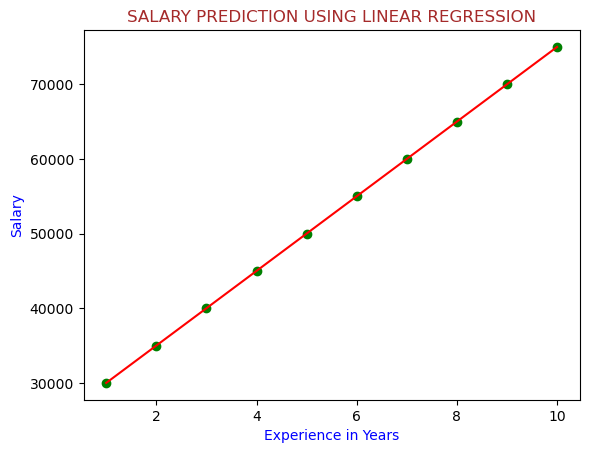

In [1]:
#                                                         *****LINEAR REGRESSION*****
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 1: Dataset
data = {
         "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
         "Salary": [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]
       }

df = pd.DataFrame(data)

# Input and Output
X = df[["Experience"]] 
y = df["Salary"]  

# Creating model
model = LinearRegression()

# Training model
model.fit(X, y)

# Getting slope and  intercept values
slope = model.coef_[0]
intercept = model.intercept_
print("Slope (m):", slope)
print("Intercept (b):", intercept)

# Step 6: Prediction
new_data = pd.DataFrame({"Experience": [12]})
model.predict(new_data)
print("Predicted Salary for 12 years:", model.predict(new_data))

# Plotting Graph
plt.scatter(X, y, color='green')
plt.plot(X, model.predict(X),color='red')  
plt.xlabel("Experience in Years",color='blue')
plt.ylabel("Salary",color='blue')
plt.title("SALARY PREDICTION USING LINEAR REGRESSION",color='brown')
plt.show()


Accuracy: 0.9736842105263158

Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        1          1
9        1          1
10       1          1
11       0          0
12       1          1
13       0          0
14       1          1
15       0          0
16       1          1
17       1          1
18       1          1
19       0          0


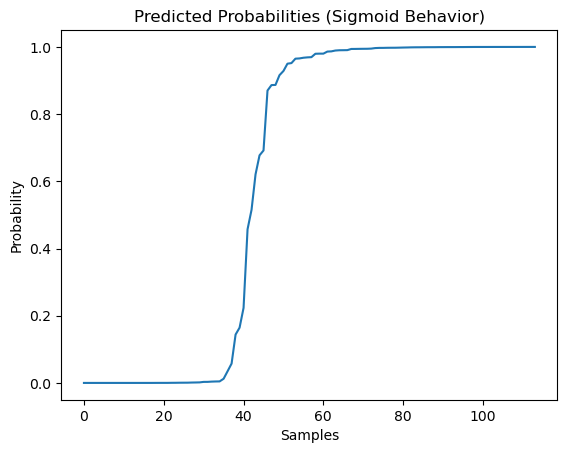

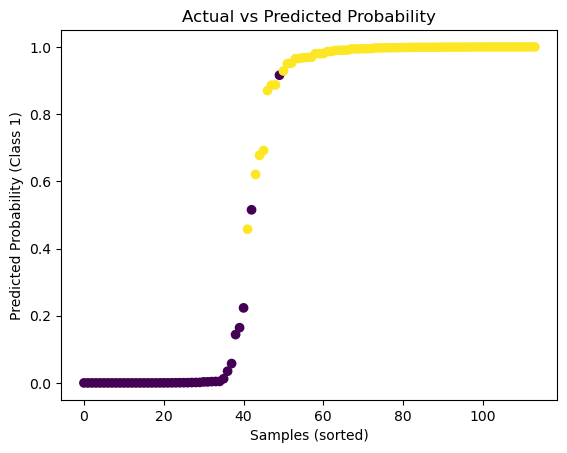

In [10]:
#                                                        *****LOGISTIC REGRESSION*****
#  Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  Loading dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Creating comparison 
results = pd.DataFrame({'Actual': y_test,'Predicted': y_pred })
print(results.head(20))   # This shows first 20 rows

#  visualization
# Sorting values for smooth curve
sorted_indices = np.argsort(y_prob)
y_prob_sorted = y_prob[sorted_indices]
y_test_sorted = y_test[sorted_indices]

#Visualization og sigmoid behavior
plt.figure()
plt.plot(y_prob_sorted)
plt.title("Predicted Probabilities (Sigmoid Behavior)")
plt.xlabel("Samples")
plt.ylabel("Probability")
plt.show()

#Visuaization of Actual and predicted probabilities
plt.figure()

# Plotting
plt.scatter( range(len(y_prob_sorted)),y_prob_sorted,c=y_test_sorted,)
plt.title("Actual vs Predicted Probability")
plt.xlabel("Samples (sorted)")
plt.ylabel("Predicted Probability (Class 1)")
plt.show()

     Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[400 rows x 3 columns]
Accuracy: 0.9125

Confusion Matrix:
 [[48  4]
 [ 3 25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80


prediction on new data [[65, 50000]]
[1] Customer will BUY the product


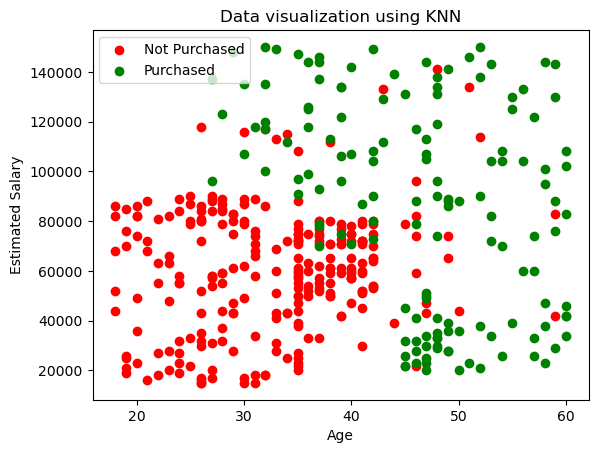

In [28]:
#Importing libraries                                                    *****KNN CLASSIFIER*****
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#loading dataset
dataset = pd.read_csv("C:/Users/allad/Downloads/Social_Network_Ads.csv")
print(dataset)
#Selecting features and target
X = dataset.iloc[:, [0, 1]].values 
y = dataset.iloc[:, 2].values      
#data splitting
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
#feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
#traininf the model
model= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
model.fit(X_train, y_train)
#prediction
y_pred = model.predict(X_test)
#evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
#prediction on new data
new_data = [[65, 50000]]
print("\nprediction on new data",new_data)
new_data_scaled = sc.transform(new_data)
prediction = model.predict(new_data_scaled)
if prediction[0] == 1:
    print(prediction,"Customer will BUY the product")
else:
    print(prediction,"Customer will NOT BUY the product")
#visualization
plt.scatter(X0[:, 0], X0[:, 1], c='red', label='Not Purchased')
plt.scatter(X1[:, 0], X1[:, 1], c='green', label='Purchased')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Data visualization using KNN')
plt.legend()
plt.show()

In [10]:
#                                                  *****NAIVE BAYES CLASSIFIER*****
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
data = pd.read_csv("C:/Users/allad/Downloads/spam.csv", encoding='latin-1')
data = data[['v1', 'v2']]
data.columns = ['label', 'message']
print(data.head())
data['label'] = data['label'].map({'ham': 0, 'spam': 1})
X = data['message']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
cv = CountVectorizer()
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_pred))
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(result.head(20))
#new data
msg = ["Congratulations! You won a free ticket"]
print("new meassage: ",msg)
msg = cv.transform(msg)
prediction = model.predict(msg)
if prediction[0] == 1:
    print(" Predicted as Spam")
else:
    print("Predicted as Not Spam")


  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Accuracy:  0.9838565022421525
Confusion matrix: 
[[963   2]
 [ 16 134]]
    Actual  Predicted
0        0          0
1        0          0
2        1          1
3        0          0
4        1          1
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       1          1
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       1          1
18       0          0
19       0          0
new meassage:  ['Congratulations! You won a free ticket']
 Predicted as Spam


  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

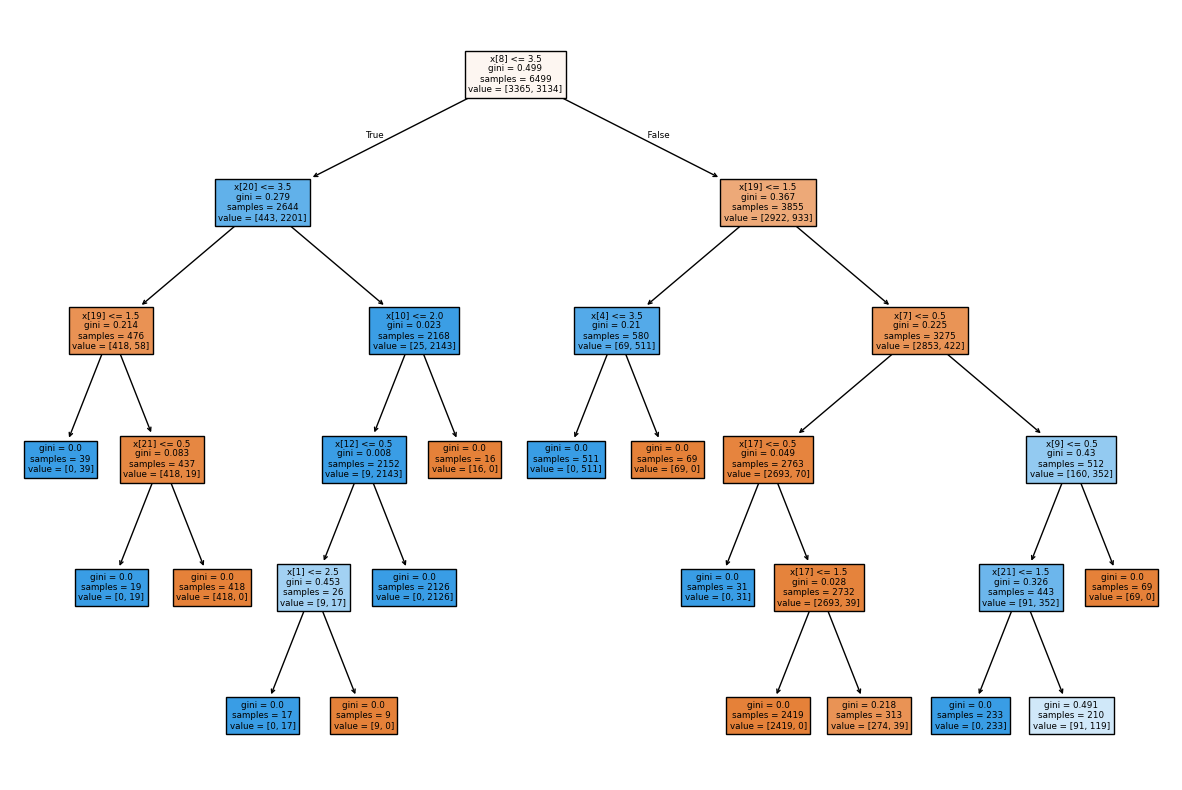

In [4]:
#                                                     *****DECISION TREE CLASSIFIER*****
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Load dataset
data = pd.read_csv("C:/Users/allad/Downloads/mushrooms.csv")
print(data.head())
#label encoding
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])
# Features & Target
X = data.drop('class', axis=1)
y = data['class']
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
# Model training
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
# Prediction
y_pred = model.predict(X_test)
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test,y_pred))
result = pd.DataFrame({'Actual': y_test,'Predicted': y_pred })
print(result.head(10))
#visualization of tree
plt.figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()